In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
from src.tracking.track import Track
from src.tracking.track_manager import TrackManager
from src.tracking.extended_kf import ExtendedKalmanFilter
from src.evaluation import metrics, plotting
from src.scenarios import (
    truth_generator_ra,
)  # generate truth measurements based on config

In [3]:
from src.models import (
    measurement_models,
    motion_models,
) 

In [4]:
from configs.multi_track_ss_range_azimuth import (
    R,
    Q,
    P0,
    truth_data,
    id_miss_index,
    dt,
    Q,
    measurement_noise,
    ss_baseline_seed,
)  # everything here comes just from baseline

In [5]:
def angle_between(v1, v2):
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot_product = np.dot(v1_u, v2_u)
    angle_rad = np.arccos(np.clip(dot_product, -1.0, 1.0))

    return np.degrees(angle_rad)

In [6]:
sensor_position = np.array([[0.0],[150.0]])

In [7]:
ss_baseline_seed()

truth_states, truth_positions, truth_velocities, truth_times, truth_exists, scans = (
    truth_generator_ra.generate_truth(
        200,
        truth_data,
        id_miss_index,
        R,
        dt,
        measurement_noise,
        sensor_position,
    )
)

In [8]:
def make_kf_track_factory(F, H, Q, R, P0):
    def factory(track_id, z_k):
        x0 = np.array([
            [z_k[0, 0]],
            [z_k[1, 0]],
            [0.0],
            [0.0],
        ], dtype=float)

        return Track(
            track_id=track_id,
            kf=KalmanFilter(
                F=F,
                H=H,
                Q=Q,
                R=R,
                x_hat_km1_km1=x0,
                P_km1_km1=P0.copy(),
            ),
            tentative=True,
        )
    return factory

In [9]:
def make_ekf_track_factory(Q, R, P0, sensor_position):
    def factory(track_id, z_k):
        r = z_k[0, 0]
        b = z_k[1, 0]
        sx, sy = sensor_position.flatten()

        px = sx + r * np.cos(b)
        py = sy + r * np.sin(b)

        x0 = np.array([
            [px],
            [py],
            [0.0],
            [0.0],
            [0.0],
        ], dtype=float)

        return Track(
            track_id=track_id,
            kf=ExtendedKalmanFilter(
                Q=Q,
                R=R,
                x_hat_km1_km1=x0,
                P_km1_km1=P0.copy(),
                sensor_position=sensor_position,
            ),
            tentative=True,
        )
    return factory

In [10]:
# places all of the k-1 tracks into kf objects and track objects.
trax = [
    Track(
        track["id"],
        ExtendedKalmanFilter(
            R=R,
            Q=Q,
            x_hat_km1_km1=track["x"],
            P_km1_km1=track["P"],
            sensor_position = sensor_position
        ),
    )
    for track in truth_data
]
tracker = TrackManager(
    trax,
    5.991,
    track_factory=make_ekf_track_factory(Q, R, P0, sensor_position),
)  # all tracks are stored into the trackmanager
# truth_states - For each track id x_i_t = [p_x, p_y, v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_positions - For each track id x_i_t = [p_x, p_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_velocities - For each track id x_i_t = [v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_times - delta = 1.5, t = {delta*i, delta*i+1,...} for i = {0,1, 2, ... 100}
# truth_exists - truth_exists = {1 if track_i should have a hit at t = k, 0 otherwise}
# scans - {z_1, z_2, z_3, ...} for z_i in F@x + v(0, R) for timestep k_j , j = {k, k+1, ...}
tracker.scan_log[0] = {
    "time": truth_times[0],
    "num_measurements": 0,
    "num_tracks": len(tracker.tracks),
}

for index, measurements in scans.items():
    # print(measurements)
    # break
    tracker.scan_log[index] = {
        "time": truth_times[index],
        "num_measurements": len(measurements),
        "num_tracks": len(tracker.tracks),
    }
    tracker.predict_all()
    assignments, unassigned_tracks, unassigned_measurements, _ = tracker.gnn_associate(
        measurements, index
    )

    assignment_map = {a["track_id"]: a["measurement"] for a in assignments}
    unassigned_track_ids = {t["track_id"] for t in unassigned_tracks}
    tracks_to_delete = []
    tracker.pred_log[index] = {}

    for trk in tracker.tracks:
        tracker.pred_log[index][trk.track_id] = [trk.kf.x_hat_k_km1, trk.kf.P_k_km1]

        if trk.track_id in assignment_map:
            z_k = assignment_map[trk.track_id]  # Get measurement from ass map

            trk.update(z_k)  # use measurement / prediction to update
            if trk.track_id in truth_states.keys():
                tracker.log_error(trk, truth_states[trk.track_id][index])
            if trk.tentative:  # if its a tentative track increase hit count by 1
                trk.hit_count += 1
                if trk.hit_count >= 20:  # promote track if hit count >= 2
                    trk.promote_track()
                    print(
                        f"Index: {index}. tentative Track ID: {trk.track_id} Promoted! Hit Count: {trk.hit_count}"
                    )
            print(f"Index: {index}. Track {trk.track_id} Detected!")

        elif (
            trk.track_id in unassigned_track_ids
        ):  # if this track id is unassigned then mark as a miss and coast
            # predication from k|k-1 -> k|k
            trk.miss()
            trk.coast()
            print(f"Index: {index}.  Track {trk.track_id} Missed Detection!")

        if (
            trk.tentative and trk.missed_count >= 4
        ): 
            print(
                f"Index: {index}. tentative Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 4"
            )
            tracks_to_delete.append(trk)

        elif (not trk.tentative) and trk.missed_count >= 10:
            print(
                f"Index: {index}. Confirmed Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 10"
            )
            tracks_to_delete.append(trk)

    for trk in tracks_to_delete: 
        tracker.delete_track(trk)

    for meas_info in unassigned_measurements:
        z_k = meas_info["measurement"]
        ten_track_id = tracker.create_tentative_from_measurement(z_k)
        if ten_track_id is not None:
            print(f"Index: {index}. Tentative Track ID: {ten_track_id} Created!")

Index: 1.  Track 1 Missed Detection!
Index: 1. Track 2 Detected!
Index: 1. Track 4 Detected!
Index: 1. Track 3 Detected!
Index: 2. Track 1 Detected!
Index: 2. Track 2 Detected!
Index: 2. Track 4 Detected!
Index: 2. Track 3 Detected!
Index: 3. Track 1 Detected!
Index: 3. Track 2 Detected!
Index: 3. Track 4 Detected!
Index: 3. Track 3 Detected!
Index: 4. Track 1 Detected!
Index: 4. Track 2 Detected!
Index: 4. Track 4 Detected!
Index: 4. Track 3 Detected!
Index: 5. Track 1 Detected!
Index: 5. Track 2 Detected!
Index: 5. Track 4 Detected!
Index: 5. Track 3 Detected!
Index: 6. Track 1 Detected!
Index: 6. Track 2 Detected!
Index: 6. Track 4 Detected!
Index: 6. Track 3 Detected!
Index: 7. Track 1 Detected!
Index: 7. Track 2 Detected!
Index: 7. Track 4 Detected!
Index: 7. Track 3 Detected!
Index: 8. Track 1 Detected!
Index: 8. Track 2 Detected!
Index: 8. Track 4 Detected!
Index: 8. Track 3 Detected!
Index: 9. Track 1 Detected!
Index: 9. Track 2 Detected!
Index: 9. Track 4 Detected!
Index: 9. T

In [11]:
rmse, _, n = metrics.position_rmse_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
per_track_rmse = metrics.position_rmse_per_track_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
coverage = metrics.track_coverage_from_truth_and_predlog(truth_states, tracker.pred_log)
print("Total Tracks:", max([x.track_id for x in tracker.tracks]))
print("Overall RMSE:", rmse)
print("Per-track RMSE:", per_track_rmse)
print("Coverage:", coverage)
print("Matched samples:", n, "of", int(n / coverage))

Total Tracks: 4
Overall RMSE: 1.5036596955517159
Per-track RMSE: {1: 1.4598456240002569, 2: 1.6135809535418346, 4: 1.52738942468083, 3: 1.4057946955136105}
Coverage: 1.0
Matched samples: 800 of 800


In [12]:
metrics.nis_metrics(tracker, truth_data) # NIS BASED

Track_2 NIS: 1.0827141718013857
Track_4 NIS: 1.0917389001513262
Track_3 NIS: 0.8994334264849897
Track_1 NIS: 1.01696115104014
------

Overall NIS: 1.0219482626125105


In [13]:
metrics.nees_metrics(tracker, truth_data)

Track_2 NEES: 2.4761504533297236
Track_4 NEES: 2.6178636827149893
Track_3 NEES: 2.301791643264073
Track_1 NEES: 2.2181056641552446
------

Overall NEES: 2.4034267881436775


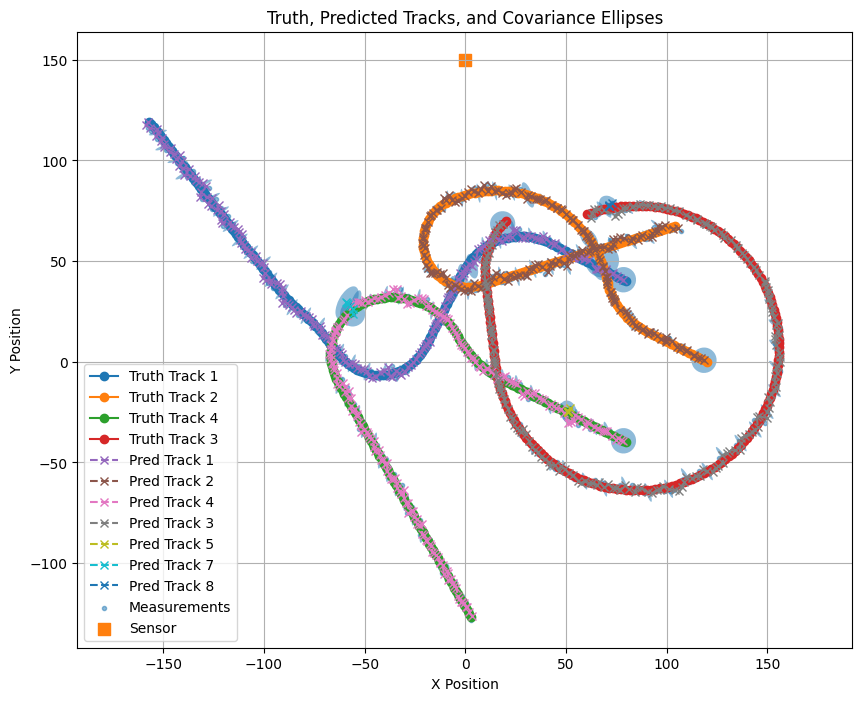

In [14]:
sensor_position = np.array([[0.0], [150.0]])

plotting.plot_tracks(
    truth_positions,
    tracker,
    scans=scans,
    sensor_position=sensor_position,
    confidence=0.95,
    ellipse_every=5,   # try 2 or 3 if the plot gets too crowded
    ellipse_alpha=0.50,
    show_scan_labels=False,
    show_measurements=True,
)

In [15]:
avg_ospa,median_ospa, per_scan_ospa, per_scan_details = metrics.ospa_from_truth_tracks_and_predlog(
    truth_states=truth_states,
    pred_log=tracker.pred_log,
    c=30.0,
    p=1,
    components=(0, 1,2,3)
)

print("Average OSPA:", avg_ospa)
print("Median OSPA:", median_ospa)
for k in sorted(per_scan_details.keys()):
    d = per_scan_details[k]
    print(
        f"Scan {k}: "
        f"OSPA={per_scan_ospa[k]:.3f}, "
        f"loc={d['localization_component']:.3f}, "
        f"card={d['cardinality_component']:.3f}"
    )



Average OSPA: 1.9716550799837353
Median OSPA: 1.3050074147216948
Scan 0: OSPA=30.000, loc=0.000, card=0.000
Scan 1: OSPA=0.029, loc=0.029, card=0.000
Scan 2: OSPA=0.456, loc=0.456, card=0.000
Scan 3: OSPA=0.414, loc=0.414, card=0.000
Scan 4: OSPA=1.207, loc=1.207, card=0.000
Scan 5: OSPA=0.630, loc=0.630, card=0.000
Scan 6: OSPA=1.594, loc=1.594, card=0.000
Scan 7: OSPA=0.423, loc=0.423, card=0.000
Scan 8: OSPA=1.380, loc=1.380, card=0.000
Scan 9: OSPA=0.663, loc=0.663, card=0.000
Scan 10: OSPA=1.011, loc=1.011, card=0.000
Scan 11: OSPA=1.570, loc=1.570, card=0.000
Scan 12: OSPA=1.892, loc=1.892, card=0.000
Scan 13: OSPA=1.077, loc=1.077, card=0.000
Scan 14: OSPA=1.299, loc=1.299, card=0.000
Scan 15: OSPA=0.483, loc=0.483, card=0.000
Scan 16: OSPA=0.694, loc=0.694, card=0.000
Scan 17: OSPA=0.781, loc=0.781, card=0.000
Scan 18: OSPA=2.228, loc=2.228, card=0.000
Scan 19: OSPA=7.292, loc=1.292, card=6.000
Scan 20: OSPA=6.951, loc=0.951, card=6.000
Scan 21: OSPA=6.542, loc=0.542, card=6.00